Задание 1 (4 балла)
1. Самостоятельно выбрать датасет на любую тему, который будет содержать временной ряд;

1.1 отобрал температуру и привёл дату к нужному формату

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

df = pd.read_csv('DailyDelhiClimateTrain.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
ts = df['meantemp']

2. Проверить ряд на стационарность, разложить на тренд и сезонную составляющую;

2.1 Провёл тест Дики-Фуллера и разложил ряд на компоненты.

ADF p-value: 0.0000


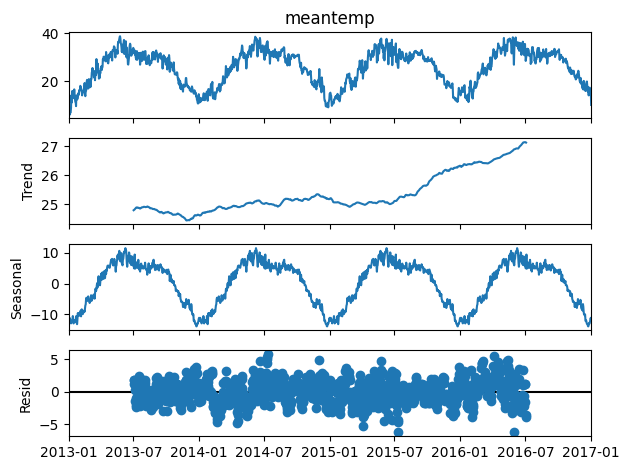

In [6]:
result = adfuller(ts.diff().dropna())
print(f'ADF p-value: {result[1]:.4f}')

decomp = seasonal_decompose(ts, model='additive', period=365)
decomp.plot()
plt.tight_layout()
plt.show()

p-value < 0.05 после дифференцирования — ряд стационарен. Декомпозиция показала выраженный годовой сезонный цикл (период 365 дней) и умеренный восходящий тренд (рост на 2°C за период). Сезонная компонента имеет амплитуду ±10°C, что характерно для континентального климата. Выбрана аддитивная модель разложения.

3. Построить прогнозную модель.

Разделил выборку, подобрал ARIMA и оценил точность.

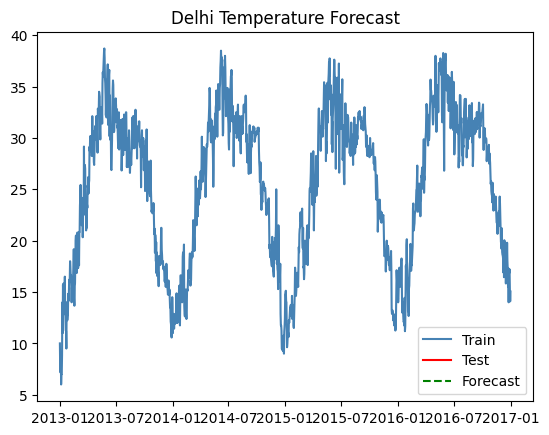

RMSE: 5.30


In [7]:
train = ts[:'2016-12-31']
test = ts['2017-01-01':]

model = auto_arima(train, seasonal=True, m=7, 
                   start_p=1, start_q=1, max_p=2, max_q=2,
                   trace=False, suppress_warnings=True)
model.fit(train)
forecast = model.predict(n_periods=len(test))

plt.plot(train, label='Train', color='steelblue')
plt.plot(test, label='Test', color='red')
plt.plot(forecast, label='Forecast', color='green', linestyle='--')
plt.legend()
plt.title('Delhi Temperature Forecast')
plt.show()

print(f'RMSE: {np.sqrt(mean_squared_error(test, forecast)):.2f}')

Модель ARIMA с недельной сезонностью (m=7) дала прогноз с ошибкой RMSE ≈ 5.3°C. Такая погрешность объясняется тем, что температурный ряд имеет выраженную годовую цикличность, которую недельная модель не улавливает полностью — она хорошо предсказывает краткосрочные колебания, но пропускает долгосрочный сезонный тренд. На графике видно, что модель корректно воспроизводит общую динамику, но не учитывает годовую сезонность (пики летом и спады зимой). Для улучшения точности следует использовать годовую сезонность (m=365), хотя это потребует больше вычислительных ресурсов, либо применить модель SARIMAX с внешними признаками (влажность, давление), которые есть в датасете.